## What are the most in-demand skills for Top 3 most popular Data Roles?

Methodology
 
 1. Clean up skills column
 2. Calculate skills based `job_title_short`
 3. Calculate skill percentage
 4. Plot final findings

## Importing Libraries and data

In [2]:
#libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#loading data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
#cleaning
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Filter down the data for US market & Explode Skills
After filtering te data for US market, converts the `job_skills` column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the job_title and `job_skills` columns, allowing us to analyze the distribution of skills across different data job titles.

In [20]:
df_US = df[df['job_country']=='United States'].copy()
df_skills = df_US.explode('job_skills')

## Count Skills per Job Title
Groups DataFrame by `job_skills` and `job_title_short`, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to `skills_count`. The final DataFrame, df_`skills_count`, shows the frequency of each skill with each job title in descending order by the count of skills.

In [8]:
# Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()
# Name the count column as skills_count and reset the index.
df_skills_count = df_skills_count.reset_index(name='skills_count')
# Sort the DataFrame by skills_count in descending order
df_skills_count = df_skills_count.sort_values(by='skills_count',ascending=False)
df_skills_count.sample(5)

,job_skills,job_title_short,skills_count
576,github,Data Scientist,2080
1283,redis,Senior Data Scientist,55
864,microsoft teams,Machine Learning Engineer,3
745,jupyter,Data Engineer,446
894,mongo,Data Engineer,921


## Create List of Top 3 Roles

**Focus:** Data Analysts, Data Engineers, and Data Scientists.

**Filter:** the job titles based on the most popular.

In [5]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

## Plot Skill Counts

Creates a stacked horizontal bar chart for the top 5 skills for Top 3 roles, displaying the frequency of each skill.

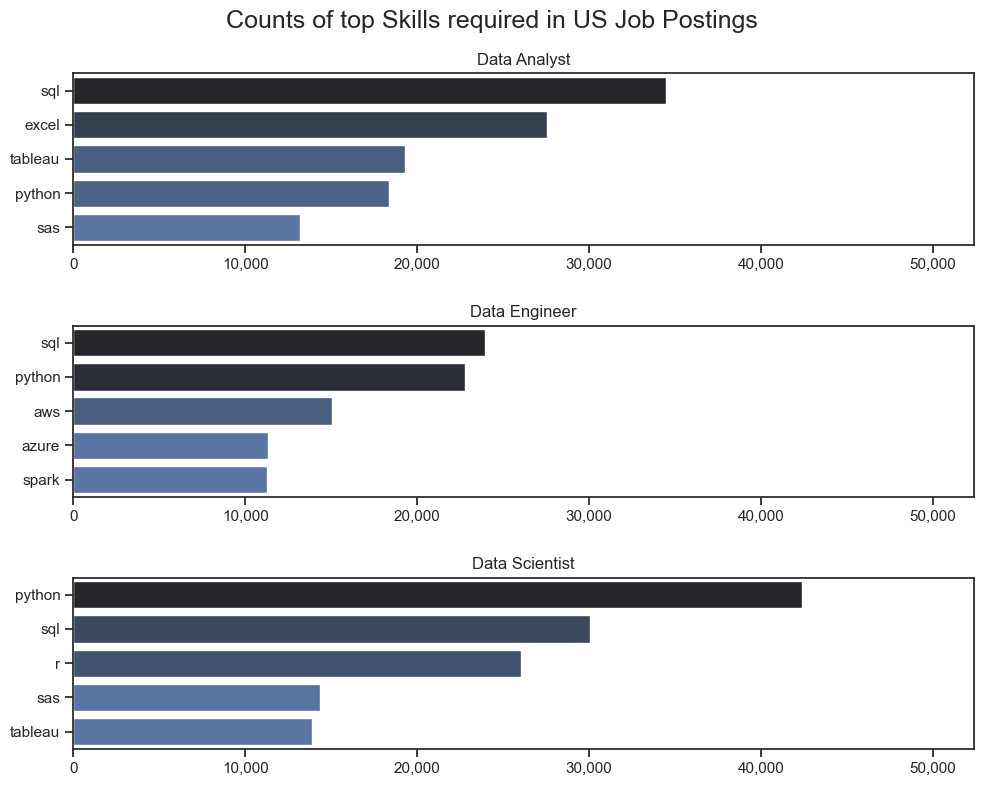

In [9]:
fig, ax = plt.subplots(len(job_titles),1,figsize=(10,8))

sns.set_theme(style="ticks")
for i, v in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']==v].head()
    sns.barplot(data=df_plot, x='skills_count', y='job_skills', ax=ax[i],hue='skills_count',palette='dark:b_r', legend=False)
    ax[i].set_title(v)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
    ax[i].set_xlim(0, df_skills_count['skills_count'].max()+10000) # make the scales the same
    
fig.suptitle('Counts of top Skills required in US Job Postings', fontsize=18)    
plt.tight_layout(h_pad=2)
plt.show()

## Convert Counts to Percentages

**Focus:** Counts don't show what portions of jobs are requesting these skills
So we'll convert the counts into percentages which helps us understand how each job title represents relative to the entire dataset.

Before we can calculate the percentages we need the total counts for the jobs posted by job title. Calculate the frequency of each job title using the `value_counts()` method on the `job_title_short` column. Then reset the index to transform the Series into a DataFrame and rename the column to total. The DataFrame `df_job_title_count` now holds a list of job titles alongside their total occurrences.

In [18]:
# Use original df to get the count of job titles
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='total_jobs')

df_job_title_count

,job_title_short,total_jobs
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


Then we calculate the percentages. First merge df_skills_count and df_job_title_count, based on the 'job_title_short' column, ensuring each skill count is associated with the total number of job postings for that title. Then calculate the percentage of each skill within its job title by dividing the skill count by the total job postings and multiplying by 100, adding this new data as a 'percentage' column.

In [19]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = ((df_skills_perc['skills_count'] / df_skills_perc['total_jobs']) * 100).round(2)

df_skills_perc.head(10)

,job_skills,job_title_short,skills_count,total_jobs,skill_percent
0,python,Data Scientist,42379,58830,72.04
1,sql,Data Analyst,34452,67816,50.80
2,sql,Data Scientist,30034,58830,51.05
3,excel,Data Analyst,27519,67816,40.58
4,r,Data Scientist,26022,58830,44.23
5,sql,Data Engineer,23958,35080,68.30
6,python,Data Engineer,22762,35080,64.89
7,tableau,Data Analyst,19311,67816,28.48
8,python,Data Analyst,18382,67816,27.11
9,aws,Data Engineer,15018,35080,42.81


## Plot Percentage Count

Filters and sorts a DataFrame to get the top 5 skills percentages for these top 3 roles. After sorting the skills by descending percentage, reverse the order of these top 5 entries to use in a horizontal bar plot, which by default starts plotting from the bottom.

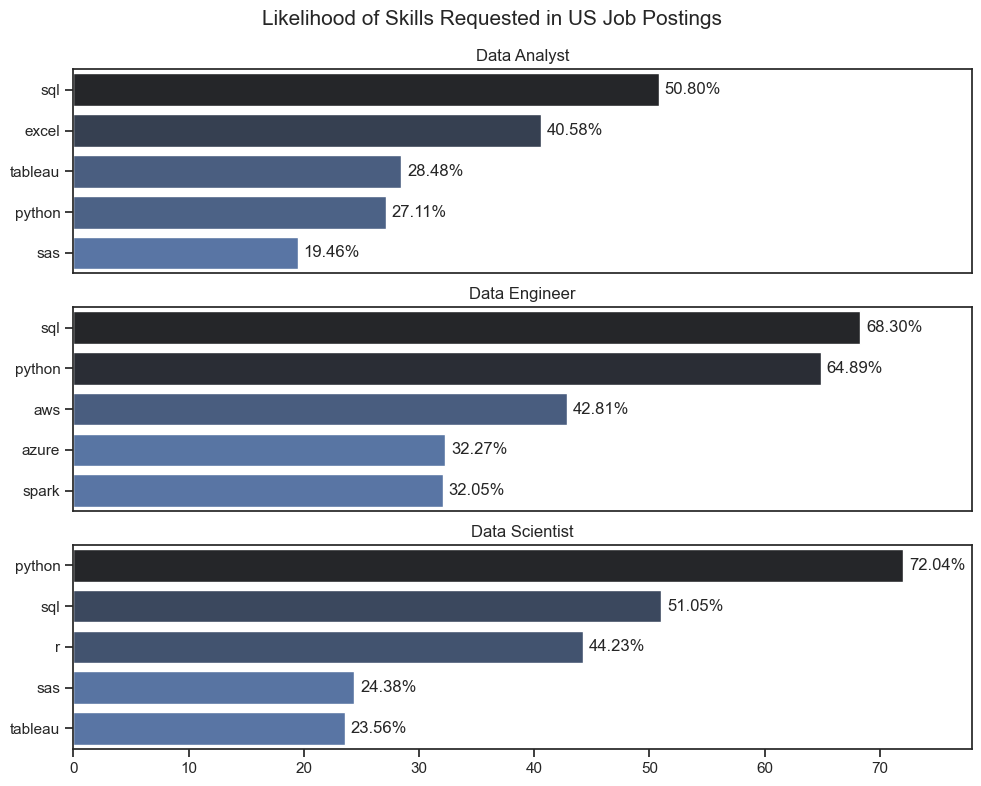

In [15]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 8))


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skills_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
 # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

 # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 0.5, n, f'{v:.2f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()